In [41]:
%pip install -U -q 'instructor[vertexai]' 'anthropic[vertex]' langgraph langchain_huggingface langchain-community langchain_experimental  httpx sentence_transformers

# Inputs

In [25]:
ontology = """
metadata:
  name: Form10K_2023
  type: financial_report
  about: Annual report containing company's financial statements and operations
  filingDate: 2023-12-31
  context: Contains high level information about the document processed
  company:
    entity: Company

sections:
  - entity: PartI
    subsections:
      - Business
      - RiskFactor
      - LegalProceeding
      - MineSafety

entities:
  - name: Company
    properties:
      - name: Name of the company
      - cik: cusip number
  - name: PartI
    properties:
      - id: Identifier for Part I
    relationships:
      - type: HAS_BUSINESS
        target: Business
      - type: HAS_RISK_FACTOR
        target: RiskFactor
      - type: HAS_LEGAL_PROCEEDING
        target: LegalProceeding
      - type: HAS_MINE_SAFETY
        target: MineSafety
  - name: Business
    properties:
      - id: Identifier for business section
      - description: General business description
      - seasonality: Business seasonality patterns
      - employees: Number of employees
      - regulatoryEnvironment: Regulatory framework description
    relationships:
      - type: HAS_SEGMENT
        target: BusinessSegment
      - type: HAS_PRODUCT
        target: Product
      - type: HAS_COMPETITION
        target: Company
      - type: HAS_RAW_MATERIAL
        target: RawMaterial
      - type: HAS_INTELLECTUAL_PROPERTY
        target: IntellectualProperty
  - name: BusinessSegment
    properties:
      - name: Name of the segment
  - name: Product
    properties:
      - name: Name of the product
  - name: RawMaterial
    properties:
      - name: Name of the raw material
  - name: IntellectualProperty
    properties:
      - name: Name of the IntellectualProperty
  - name: RiskFactor
    properties:
      - id: Risk factor identifier
      - description: General risk description
      - potentialImpact: Potential impact of the risk on business
      - mitigationStrategy: Risk mitigation strategy
    relationships:
    - type: HAS_RISK_CATEGORY
      target: RiskCategory
  - name: RiskCategory
    properties:
      - name: Name of the Risk Category
  - name: LegalProceeding
    properties:
      - id: Legal proceeding identifier
      - description: Legal case description
      - jurisdiction: Legal jurisdiction
      - status: Current proceeding status
      - potentialLiability: Potential financial liability
      - expectedResolution: Expected resolution timeline
  - name: MineSafety
    properties:
      - id: Mine safety record identifier
      - violations: Number of safety violations
      - assessments: Number of financial assessments or penalties
    relationships:
      - type: HAS_CITATION
        target: Citation
  - name: Citation
    properties:
      - name: Citation name
      - description: Citation description
"""

In [26]:
text = """Title: PART I\n  Title: Items 1 and 2. Business and Properties.\n  Title: General\n  Adams Resources & Energy, Inc. (“AE”) is a publicly traded Delaware corporation organized in 1973. Our common shares are listed on the NYSE American LLC (“NYSE American”) under the ticker symbol “AE”. Through our subsidiaries, we are primarily engaged in crude oil marketing, truck and pipeline transportation of crude oil, and terminalling and storage in various crude oil and natural gas basins in the lower 48 states of the United States (“U.S.”). In addition, we conduct tank truck transportation of liquid chemicals, pressurized gases, asphalt and dry bulk primarily in the lower 48 states of the U.S. with deliveries into Canada and Mexico, and with seventeen terminals across the U.S. We also recycle and repurpose off-specification fuels, lubricants, crude oil and other chemicals from producers in the U.S. Our headquarters are located in 22,197 square feet of office space located at 17 South Briar Hollow Lane, Suite 100, Houston, Texas 77027. Unless the context requires otherwise, references to “we,” “us,” “our,” the “Company” or “AE” are intended to mean the business and operations of Adams Resources & Energy, Inc. and its consolidated subsidiaries.\nWe operate and report in four business segments: (i) crude oil marketing, transportation and storage; (ii) tank truck transportation of liquid chemicals, pressurized gases, asphalt and dry bulk; (iii) pipeline transportation, terminalling and storage of crude oil; and (iv) interstate bulk transportation logistics of crude oil, condensate, fuels, oils and other petroleum products and recycling and repurposing of off-specification fuels, lubricants, crude oil and other chemicals. For detailed financial information regarding our business segments, see Note 9 in the Notes to Consolidated Financial Statements included under Part II, Item 8 of this annual report.\n\n\nTitle: Business Segments\n  Title: Crude Oil Marketing\n  Our crude oil marketing segment consists of the operations of our wholly owned subsidiary, GulfMark Energy, Inc. (“GulfMark”). Our crude oil marketing activities generate revenue from the sale and delivery of crude oil purchased either directly from producers or from others on the open market. We also derive revenue from third party transportation contracts. We purchase crude oil and arrange sales and deliveries to refiners and other customers, primarily onshore in Texas, North Dakota, Michigan, Wyoming, Colorado and Louisiana. 2\nOur crude oil marketing activities includes a fleet of 163 tractor-trailer rigs, the majority of which we own and operate, used to transport crude oil. We also maintain approximately 180 pipeline inventory locations or injection stations. We have the ability to barge crude oil from six crude oil storage facilities along the Intracoastal Waterway of Texas and Louisiana, and we have access to approximately 889,000 barrels of storage capacity at the dock facilities in order to access waterborne markets for our products.\nThe following table shows the age of our owned and leased tractors and trailers within our crude oil marketing segment at December 31, 2023:\n____________________ (1) Includes twenty-seven 2024 tractors, twenty-one 2023 tractors, sixteen 2021 tractors and five 2019 tractors that we lease from third parties under finance lease agreements. (2) Includes two 2024 trailers, one 2007 trailer and two 2004 trailers that we lease from third parties under finance lease agreements. See Note 17 in the Notes to Consolidated Financial Statements for further information.\nWe purchase crude oil at the field (wellhead) level. Volume and price information were as follows for the periods indicated:\n____________________ (1) Reflects the volume purchased from third parties at the field level of operations. 3\nField level purchase volumes depict our day-to-day operations of acquiring crude oil at the wellhead, transporting crude oil, and delivering it to market sales points. We held crude oil inventory at a weighted average composite price as follows at the dates indicated (in barrels):\nWe deliver physical supplies to refinery customers or enter into commodity exchange transactions from time to time to protect from a decline in inventory valuation. During the year ended December 31, 2023, we had sales to two customers that comprised approximately 11.4 percent and 11.1 percent, respectively, of total consolidated revenues. We believe alternative market outlets for our commodity sales are readily available and a loss of any of these customers would not have a material adverse effect on our operations. See Note 19 in the Notes to Consolidated Financial Statements for further information regarding credit risk.\nOperating results for our crude oil marketing segment are sensitive to a number of factors. These factors include commodity location, grades of product, individual customer demand for grades or location of product, localized market price structures, availability of transportation facilities, actual delivery volumes that vary from expected quantities, and the timing and costs to deliver the commodity to the customer.\n\n\nTitle: Transportation\n  Our transportation segment consists of the operations of our wholly owned subsidiary, Service Transport Company (“STC”). STC transports liquid chemicals, pressurized gases, asphalt and dry bulk on a “for hire” basis throughout the continental U.S., and into Canada and Mexico. For deliveries into Mexico, our drivers meet a third party carrier at the border, and the third party contractor delivers the products to the customer within Mexico. We do not own any of the products that we haul; rather we act as a third party carrier to deliver our customers’ products from point A to point B, using predominately our employees and our owned or leased tractors and trailers. However, we also use contracted independent owner operators to provide transportation services. Transportation services are provided to customers under multiple load contracts in addition to loads covered under STC’s standard price list. Our customers include major oil and chemical companies and large and mid-sized industrial companies.\nSTC operates seventeen terminals in ten states: (i) Texas, with terminals in Houston, Corpus Christi, Nederland and Freeport; (ii) Louisiana, with terminals in Baton Rouge (St. Gabriel), St. Rose and Sterlington; (iii) Florida, with terminals in Jacksonville and Tampa; (iv) Augusta, Georgia; (v) Mobile, Alabama; (vi) Charlotte, North Carolina; (vii) Cincinnati, Ohio; (viii) South Charleston, West Virginia; (ix) Memphis, Tennessee; and (x) Illinois, with terminals in East St. Louis and Joliet. The St. Gabriel, Louisiana and the Corpus Christi, Texas terminals are situated on 11.5 acres and 3.5 acres, respectively, that we own, and both include an office building, maintenance bays and tank cleaning facilities.\nTransportation operations are headquartered at a terminal facility situated on 26.5 acres that we own in Houston, Texas. This property includes maintenance facilities, administrative offices and terminal facility, tank wash rack facilities and a water treatment system. Pursuant to regulatory requirements, STC holds a Hazardous Materials Certificate of Registration issued by the U.S. Department of Transportation (“DOT”).\nThe following table shows the age of our owned and leased tractors and trailers within our transportation segment at December 31, 2023:\n____________________ (1) Excludes 90 contracted independent owner operator tractors. (2) Includes fifteen 2024 tractors, thirty-five 2023 tractors and thirty-three 2021 tractors that we lease from third parties under finance lease agreements. (3) Includes fourteen 2024 trailers, twenty-two 2023 trailers, twenty 2020 trailers and twenty 2018 trailers that we lease from third parties under finance lease agreements. See Note 17 in the Notes to Consolidated Financial Statements for further information.\nMiles traveled was as follows for the periods indicated (in thousands):\nAll company and independent contractor tractors are equipped with in-cab communication technology, enabling two-way communications between our dispatch office and our drivers, through both standardized and free-form messaging, including electronic logging. We have also installed electronic logging devices (ELDs) on 100 percent of our tractor fleet. This technology enables us to dispatch drivers efficiently in response to customers’ requests and to provide real-time information to customers about the status of their shipments. We have also equipped our tractor fleet with forward-facing and inward facing event recorders. These cameras are constantly recording the movements of the vehicles, and our management team is alerted via email in the event the unit triggers a G-force event. A snapshot of this recording is then sent to our management team for review.\nSTC holds the American Chemistry Council’s certification as a Responsible Care Management System (“RCMS”) company. The scope of this RCMS certification covers the carriage of bulk liquids throughout STC’s area of operations as well as the tank trailer cleaning facilities and equipment maintenance. Certification was granted based on STC’s conformance to the RCMS’s comprehensive environmental health, safety and security requirements. STC’s quality management process is one of its major assets. The practice of using statistical process control covering safety, on-time performance and customer satisfaction aids continuous improvement in all areas of quality service. 5\nSTC is a Partner in the U.S. Environmental Protection Agency’s (“EPA”) SmartWay Transport Partnership, a national voluntary program developed by the EPA and freight industry representatives to reduce greenhouse gases and air pollution and promote cleaner, more efficient ground freight transportation.\nDuring 2020, STC applied for and received its first bronze star rating from EcoVadis, a global leader in monitoring, benchmarking and enabling sustainability in global supply chains.\nDuring 2022, STC won the National Tank Truck Carriers’ (“NTTC”) Heil Trophy Award for its 2021 efforts. This esteemed award recognizes tank truck operations in North America with the best safety program and safety record for the year. STC claimed NTTC’s Heil Trophy Award in the Harvison division, which spotlights carriers whose trucks traveled more than 15 million miles during the previous year. NTTC’s longest-running safety contest annually recognizes North American for-hire and private tank truck fleets with elite safety programs and records. Winners are determined by their safety records, safety and preventive maintenance programs, personnel safety programs and record, and contributions to tank truck industry and general highway safety causes.\nSTC is a member of Texas TRANSCAER®, a non-profit organization with membership from the chemical, transportation and emergency response industries. The mission of Texas TRANSCAER® is to promote safe transportation and handling of hazardous materials, educate about the safety and security of hazardous materials that are transported through communities, and provide education and training for emergency responders along transportation routes. As members of Texas TRANSCAER®, STC Safety Personnel assist with training events for first responders all over Texas.\nOur strategy is to build long-term relationships with our customers based upon the highest level of customer service, safety and reliability. We believe that our commitment to safety, flexibility, size and capabilities provide us with a competitive advantage over other carriers.\n\n\nTitle: Pipeline and Storage\n  Our pipeline and storage segment consists of the operations of two of our wholly-owned subsidiaries, which constitute the VEX Pipeline System: (i) Victoria Express Pipeline, L.L.C. (“VEX”), which we acquired on October 22, 2020 and which owns the VEX pipeline, and (ii) GulfMark Terminals, LLC (“GMT”), which was formed in October 2020 to hold the related terminal facility assets we acquired with the VEX Pipeline System. The VEX Pipeline System complements our existing storage terminal and dock at the Port of Victoria, where with our crude oil marketing segment, we control approximately 450,000 barrels of storage with three docks.\nThrough 2021, pipeline and storage segment revenues were earned from a third-party shipper under a contract that had been in place at the time of the acquisition, and revenues were also earned from GulfMark, an affiliated shipper. The third-party contract ended in 2021, and all pipeline and storage segment revenues through mid-2023 were earned from GulfMark. In mid-2023, we began receiving revenue from an unaffiliated shipper. We are also currently constructing a new pipeline connection between the VEX Pipeline System and the Max Midstream pipeline system, and we expect to complete construction and place the assets into commercial service during the second half of 2024. In addition, we are exploring new connections with several other pipeline systems, for new crude oil supply opportunities both upstream and downstream of the pipeline, to enhance the crude oil supply and take-away capability of the system.\nVolume information was as follows for the periods indicated (in barrels per day):\nThe VEX Pipeline System, with truck and storage terminals at both Cuero and the Port of Victoria, Texas, is a crude oil and condensate pipeline system, which connects the heart of the Eagle Ford Basin to the Gulf Coast waterborne market. The VEX Pipeline System includes 56 miles of 12-inch pipeline, which spans DeWitt County to Port of Victoria in Victoria County, Texas, with approximately 400,000 barrels of above ground storage at its two terminals. The pipeline system has a current capacity of 90,000 barrels per day and is regulated by the Federal Energy Regulatory Commission (“FERC”) and the Texas Railroad Commission. The VEX Pipeline System can receive crude oil by pipeline and truck, and has downstream pipeline connections to two terminals today, with potential for additional downstream connection opportunities in the future.\nThe Cuero terminal has 40,000 barrels per day of offload capacity via eight truck unloading stations, with two 100,000-barrel storage tanks and one 16,000-barrel storage tank. The Port of Victoria terminal has 30,000 barrels per day of truck offload capacity via six truck unloading stations and water access via two barge docks, which have been leased from the Port Authority in Victoria. The Port of Victoria has four 50,000-barrel storage tanks and one 10,000-barrel storage tank.\nThe VEX Pipeline System supports GulfMark’s Gulf Coast region crude oil supply and marketing business and integrates into GulfMark’s value chain, serving as the link between producers/operators and our end-user markets we supply directly along the Gulf Coast waterborne market. We have the opportunity to increase our efficiency by more effectively managing the pipeline and terminalling portion of our overall transportation costs.\n\n\nTitle: Logistics and Repurposing\n  Our logistics and repurposing segment consists of the operations of two of our wholly-owned subsidiaries, Firebird and Phoenix, which we acquired on August 12, 2022. Firebird is headquartered in Humble, Texas, and currently operates seven terminal locations throughout Texas. Firebird transports crude oil, condensate, fuels, oils and other petroleum products on a “for hire” basis largely in the Eagle Ford basin. We do not own any of the products that we haul through Firebird; rather we act as a third-party carrier to deliver our customers’ products from point A to point B, using predominately our employees and our owned or leased tractors and trailers. However, we also use contracted independent owner-operators to provide transportation services. Firebird provides transportation services to customers under multiple load contracts in addition to loads covered under its standard price list. Our customers include major oil and chemical companies and large and mid-sized industrial companies. Firebird provides transportation services to Phoenix, and crude oil transportation services to GulfMark, when additional trucking capacity is required.\nPhoenix is also headquartered in Humble, Texas. Phoenix repurposes and finds beneficial uses for off-specification fuels, lubricants, crude oil and other chemicals from producers in the U.S. With an advanced laboratory, sophisticated technology, and access to an expansive fleet of trucks, Phoenix can provide a solution for customers needing help managing off-specification fuels or oils. In addition to the removal from the customer site, Phoenix markets these refinery and plant co-products into the fuels or feedstock markets. Phoenix markets on approximately six different levels, ranging from heavy fuel oils to light-end naphthas. Phoenix utilizes Firebird’s fleet to assist in the transportation of these products, and has begun to utilize STC to also assist in the transportation of these products.\nOn May 4, 2023, we acquired approximately 10.6 acres of land in the Gulf Inland Industrial Park, located in Dayton, Texas, for approximately $1.8 million to build a new processing facility for Phoenix with rail spur and siding, product storage, and truck rack. Phoenix intends to build new infrastructure to service its existing customers and to create opportunities for growing the business. Phoenix also plans to relocate its headquarters from Humble, Texas to this new location. We expect to break ground on the Dayton facility during the second quarter of 2024. When completed, this facility will allow us to operate our rail and trucking business more efficiently, as well as open up opportunities to process a wider variety of products. 7\nThe following table shows the age of our owned and leased tractors and trailers within our logistics and repurposing segment at December 31, 2023:\n____________________ (1) Excludes 10 contracted independent owner operator tractors. (2) Includes six 2024 tractors and two 2023 tractors that we lease from third parties under finance lease agreements. See Note 17 in the Notes to Consolidated Financial Statements for further information.\nAll company and independent tractors in this segment are equipped with similar in-cab communication technology and event recorders as our STC tractors, described above under “—Transportation”. All tractors are also equipped with electronic logs.\n\n\nTitle: Investment in Unconsolidated Affiliate\n  We own an approximate 15 percent equity interest (less than 3 percent voting interest) in VestaCare, Inc., a California corporation (“VestaCare”), through Adams Resources Medical Management, Inc. (“ARMM”), a wholly owned subsidiary. We acquired our interest in VestaCare in April 2016 for a $2.5 million cash payment, which we impaired in 2017. VestaCare provides an array of software as a service (SaaS) electronic payment technologies to medical providers, payers and patients including VestaCare’s product offering, VestaPay™. VestaPay™ allows medical care providers to structure fully automated and dynamically updating electronic payment plans for their patients. We do not currently have any plans to pursue additional medical-related investments. See Note 2 in the Notes to Consolidated Financial Statements for further information.\n\n\nTitle: Competition\n  In all phases of our operations, we encounter strong competition from a number of regional and national entities. Many of these competitors possess financial resources substantially in excess of ours and may have a more expansive geographic footprint than we have. We face competition principally in establishing trade credit, pricing of available materials, quality of service and location of service. Our strategy is to build long-term partnerships with our customers based upon the safety of our operations, reliability and superior customer service.\nOur crude oil marketing segment and our logistics and repurposing segment compete with major crude oil companies and other large industrial concerns that own or control significant refining, midstream and marketing facilities. These major crude oil companies may offer their products to others on more favorable terms than those available to us.\nIn the trucking industry, the tank lines transportation business is extremely competitive and fragmented. Price, service and location are the major competitive factors in each local market.\n\n\nTitle: Seasonality\n  In the trucking industry, revenue has historically followed a seasonal pattern for various commodities and customer businesses. Peak freight demand has historically occurred in the months of September, October and November. After the December holiday season and during the remaining winter months, freight volumes are typically lower as many customers reduce shipment levels. Operating expenses have historically been higher in the winter months primarily due to decreased fuel efficiency, increased cold weather-related maintenance costs, and increased insurance claim costs attributable to adverse winter weather conditions. Revenue can also be impacted by weather, holidays and the number of business days that occur during a given period, as revenue is directly related to the available working days of shippers.\nAlthough our crude oil marketing segment and our logistics and repurposing segment are not materially affected by seasonality, certain aspects of our operations are impacted by seasonal changes, such as tropical weather conditions, energy demand in connection with heating and cooling requirements and the summer driving season.\n\n\nTitle: Inflation and Other Cost Increases\n  Most of our operating expenses are inflation-sensitive, with inflation generally producing increased costs of operations. We are experiencing increased inflation in the costs of various goods and services we use to operate our business, including the cost of equipment, tires, repairs and maintenance and compensation paid to drivers. These and other factors may continue to impact our costs, expenses and capital expenditures, and could continue to have an impact on customer demand for our services as customers manage the impact of inflation on their resources.\nIn order to mitigate the effect of price increases on our business, from time to time, we enter into monthly commodity purchase and sale contracts for up to 300,000 barrels of crude oil and commodity purchase contracts for the purchase of diesel fuel. See Note 13 in the Notes to Consolidated Financial Statements for further information regarding these contracts.\nIn addition to inflation, fluctuations in fuel prices can affect profitability. Most of our transportation contracts with customers contain fuel surcharge provisions. Although we historically have been able to pass through most long-term increases in fuel prices and operating taxes to transportation customers in the form of surcharges and higher rates, there is no guarantee that this will be possible in the future. In addition, we are not able to obtain the benefit of a fuel surcharge on the crude oil marketing segment private fleet. See “Part I, Item 1A. Risk Factors .”\n\n\nTitle: Regulatory Matters\n  We are subject to an extensive variety of evolving federal, state and local laws, rules and regulations governing the storage, transportation, manufacture, use, discharge, release and disposal of product and contaminants into the environment, or otherwise relating to the protection of the environment. Below is a non-exclusive listing of the environmental laws, each as amended, that potentially impact our business.\n• The Solid Waste Disposal Act, as amended by the Resource Conservation and Recovery Act of 1976. • The Clean Water Act of 1972. • The Clean Air Act of 1970. • The Comprehensive Environmental Response Compensation and Liability Act. • The Toxic Substances Control Act of 1976. • The Emergency Planning and Community Right-to-Know Act. • The Occupational Safety and Health Act of 1970. • Texas Clean Air Act. • Texas Solid Waste Disposal Act. • Texas Water Code. • Texas Oil Spill Prevention and Response Act of 1991.\n\n\nTitle: Railroad Commission of Texas (“RRC”)\n  The RRC regulates, among other things, the drilling and operation of crude oil and natural gas wells, the operation of crude oil and natural gas pipelines, the disposal of crude oil and natural gas production wastes, and certain storage of crude oil and natural gas in Texas. RRC regulations govern the generation, management and disposal of waste from these crude oil and natural gas operations and provide for the cleanup of contamination from crude oil and natural gas operations. These regulations primarily affect our crude oil marketing segment, our pipeline and storage segment and our logistics and repurposing segment.\n\n\nTitle: Louisiana Office of Conservation\n  The Louisiana Office of Conservation has primary statutory responsibility for regulation and conservation of crude oil, natural gas, and other natural resources in the State of Louisiana. Their objectives are to (i) regulate the exploration and production of crude oil, natural gas and other hydrocarbons, (ii) control and allocate energy supplies and distribution thereof, and (iii) protect public safety and the environment from oilfield waste, including the regulation of underground injection and disposal practices.\n\n\nTitle: Trucking Activities\n  Our crude oil marketing, transportation and logistics and repurposing businesses operate truck fleets pursuant to the authority of the DOT and various state authorities. Trucking operations must be conducted in accordance with various laws relating to pollution and environmental control as well as safety requirements prescribed by states and by the DOT. Matters such as weight and dimension of equipment are also subject to federal and state regulations. These regulations also require mandatory drug testing of drivers and require certain tests for alcohol levels in drivers and other safety personnel. The regulations also impose hours of service restrictions and mandatory rest periods. The trucking industry is subject to possible regulatory and legislative changes, such as increasingly stringent environmental requirements or limits on vehicle weight and size. Regulatory change may affect the economics of the industry by requiring changes in operating practices or by changing the demand for private and common or contract carrier services or the cost of providing truckload services. In addition, our tank wash facilities are subject to increasingly stringent local, state and federal environmental regulations.\nWe have implemented security procedures for drivers and terminal facilities. Satellite tracking transponders installed in the power units are used to communicate emergencies to us and to maintain constant information as to the unit’s location. If necessary, our terminal personnel will notify local law enforcement agencies. In addition, we are able to advise a customer of the status and location of their loads. Remote cameras and enhanced lighting coverage in the staging and parking areas have augmented terminal security. We have a focus on safety in the communities in which we operate, including leveraging camera technology to enhance driver behavior and awareness. Our crude oil marketing and transportation businesses are Partners in the EPA’s SmartWay Transport Partnership, a national voluntary program developed by the EPA and freight industry representatives to reduce greenhouse gases and air pollution and promote cleaner, more efficient ground freight transportation.\n\n\nTitle: FERC Regulation\n  The VEX Pipeline System, which we acquired in 2020, is regulated by the FERC as a common carrier interstate pipeline under the Interstate Commerce Act (“ICA”), the Energy Policy Act of 1992, and related rules and orders. The ICA and its implementing regulations give the FERC authority to regulate the rates charged for service on interstate common carrier pipelines and generally require the rates and practices of interstate liquids pipelines to be just, reasonable, not unduly discriminatory and not unduly preferential. The ICA also requires tariffs that set forth the rates a common carrier pipeline charges for providing transportation services on its interstate common carrier liquids pipelines, as well as the rules and regulations governing these services, to be maintained on file with the FERC and posted publicly. The Energy Policy Act of 1992 and its implementing regulations allow interstate common carrier liquids pipelines to annually index their rates up to a prescribed ceiling level and require that such pipelines index their rates down to the prescribed ceiling level if the index is negative. In addition, the FERC retains cost-of-service ratemaking, market-based rates and settlement rates as alternatives to the indexing approach. The ICA also permits interested parties to challenge new or changed rates and gives the FERC the authority to change rates and order refunds.\nChanges in the FERC’s methodologies for approving rates could adversely affect us. In addition, challenges to our regulated rates could be filed with the FERC and future decisions by the FERC regarding our regulated rates could adversely affect our cash flows. We believe the transportation rates currently charged by our interstate liquids pipeline is in accordance with the ICA and applicable FERC regulations. However, we cannot predict the rates we will be allowed to charge in the future for transportation services by such pipeline.\n\n\nTitle: Pipeline Safety\n  We are subject to regulation by the DOT as authorized under various provisions of Title 49 of the United States Code and comparable state statutes relating to the design, installation, testing, construction, operation, replacement and management of our pipeline facilities. Among other things, these statutes also require companies that own or operate pipelines to permit access to and copying of pertinent records, file certain reports and provide other information as required by the U.S. Secretary of Transportation. The DOT regulates natural gas and hazardous liquids pipelines through its Pipeline and Hazardous Materials Safety Administration (“PHMSA”). PHMSA continues to implement and enforce these rules and has discretion to assess significant fines should non-compliance be determined.\nThe development and/or implementation of more stringent requirements pursuant to DOT regulations, as well as any implementation of the PHMSA rules thereunder or reinterpretation of guidance by PHMSA or any state agencies with respect thereto, may result in us incurring significant and unanticipated expenditures to comply with such standards. Until any such proposed regulations or guidance are finalized or issued, the impact on our operations, if any, cannot be known.\n\n\nTitle: Regulatory Status and Potential Environmental Liability\n  Our operations and facilities are subject to numerous federal, state and local environmental laws and regulations including those described above, as well as associated permitting and licensing requirements. We regard compliance with applicable environmental regulations as a critical component of our overall operation, and devote significant attention to providing quality service and products to our customers, protecting the health and safety of our employees, and protecting our facilities from damage.\nWe have, where appropriate, implemented operating procedures at each of our facilities designed to assure compliance with environmental laws and regulation. However, given the nature of our business, we are subject to environmental risks, and the possibility remains that our ownership of our facilities and our operations and activities could result in civil or criminal enforcement and public as well as private actions against us, which may necessitate or generate mandatory cleanup activities, revocation of required permits or licenses, denial of application for future permits, and/or significant fines, penalties or damages, any and all of which could have a material adverse effect on us. See “Item 1A. Risk Factors ” for further discussion.\n\n\nTitle: Human Capital Resources\n  Title: General\n  Our business strategy and ability to serve customers relies on employing talented professionals and attracting, training, developing and retaining a skilled workforce.\nThere is substantial competition for qualified truck drivers in the trucking industry. Recruitment, training, and retention of a professional driver workforce is essential to our continued growth and fulfillment of customer needs. We hire qualified professional drivers who hold a valid commercial driver’s license, satisfy applicable federal and state safety performance and measurement requirements, and meet our hiring criteria. These guidelines relate primarily to safety history, road test evaluations, and various other evaluations, which include physical examinations and mandatory drug and alcohol testing. We provide comfortable, late model equipment, encourage direct communication with management, pay competitive wages and benefits, and offer other incentives intended to encourage driver safety, retention and long-term employment. Prior to being released for individual duty, each new hire is required to undergo a mandatory training and evaluation period by a certified driver trainer/instructor. The length of this training period will be dependent on experience and the new hire adaptation to company policies and procedures.\n\n\nTitle: Employees\n  At December 31, 2023, we employed 741 persons, of which 485, or 65 percent, were truck drivers. We believe our employee relations are satisfactory, and none of our employees are subject to union contracts or part of a collective bargaining unit.\n\n\nTitle: Independent Contractors\n  In addition to company drivers, we enter into contracts with independent contractors, who provide a tractor and a driver and are responsible for all operating expenses in exchange for an agreed upon fee structure. At December 31, 2023, we had 100 independent contractor operated tractors in our transportation and logistics and repurposing segments, which comprised approximately 17 percent of our professional truck driving fleet.\n\n\nTitle: Health and Safety\n  Safety is one of our guiding principles as we are committed to providing our employees a safe working environment. We have implemented safety programs and management practices to promote a culture of safety. We are continuously working toward maintaining a strong safety culture to emphasize the importance of our employees’ role in identifying, mitigating and communicating safety risks.\nIn light of the current COVID-19 pandemic, we have updated and implemented our pandemic plan to ensure the continuation of safe and reliable service to customers and to maintain the safety of our employees, as well as to incorporate any new governmental guidance and rules and regulations regarding workplace safety. Since the beginning of the pandemic, we have been deemed an essential entity by virtue of the transportation services we provide.\n\n\nTitle: Diversity and Inclusion\n  We are committed to providing a professional work environment where all employees are treated with respect and dignity and provided with equal opportunities. We do not discriminate based upon race, religion, color, national origin, gender (including pregnancy, childbirth, or related medical conditions), sexual orientation, gender identity, gender expression, age, status as a protected veteran, status as an individual with a disability or other applicable legally protected characteristics. We also support the hiring of veterans and are honored to provide opportunities to men and women who have served their respective countries .\nWe also partner with the Women in Trucking Association to support our efforts to advance the careers of women and gender diversity. It is our goal to empower the professional development of all employees and to operate from a mindset of sharing, caring, inclusion and equity.\nWe support basic human rights throughout our business enterprise and prohibit the use of child, compulsory or forced labor. Our employees are strictly prohibited from using our equipment to transport, or our facilities to shelter, unauthorized persons, or to take any other act in support of human trafficking or human rights abuses. Employees are required to immediately report any human trafficking concerns to the appropriate law enforcement agency.\nWe work with Truckers Against Trafficking (“TAT”) to train all over-the-road drivers on how to spot and report signs of human trafficking. Our drivers receive training from TAT and become registered as TAT trained and certified.\n\n\nTitle: Benefits\n  Our compensation and benefits programs are designed to attract, retain and motivate our employees and to reward them for their services and success. In addition to providing competitive salaries and other compensation opportunities, we offer comprehensive and competitive benefits to our eligible employees including, depending on location, life and health (medical, dental and vision) insurance, prescription drug benefits, flexible spending accounts, parental leave, disability coverage, mental and behavioral health resources, paid time off and retirement savings plan.\n\n\nTitle: Available Information\n  We electronically file certain documents with the U.S. Securities and Exchange Commission (“SEC”). We file Annual Reports on Form 10-K; Quarterly Reports on Form 10-Q; and Current Reports on Form 8-K (as appropriate); along with any related amendments and supplements thereto.\nWe also make available free of charge, through the “Investor Relations” link on our website, www.adamsresources.com , our Annual Reports on Form 10-K, Quarterly Reports on Form 10-Q, Current Reports on Form 8-K and any amendments to those reports filed or furnished pursuant to Section 13(a) or 15(d) of the Exchange Act, simultaneously with or as soon as reasonably practicable after filing such materials with, or furnishing such materials to, the SEC. The information on our website, or information about us on any other website, is not incorporated by reference into this report.\n\n\nTitle: Item 1A. Risk Factors .\n  An investment in our common stock involves certain risks. If any of the following key risks were to occur, it could have a material adverse effect on our financial position, results of operations and cash flows. In any such circumstance and others described below, the trading price of our securities could decline and you could lose part or all of your investment.\n\n\nTitle: Risk Related to our Business\n  Title: Difficulty in attracting and retaining drivers could negatively affect our operations and limit our growth.\n  There is substantial competition for qualified personnel, particularly drivers, in the trucking industry. We operate in geographic areas where there is currently a shortage of drivers. Regulatory requirements, including electronic logging, and an improving U.S. jobs market, could continue to reduce the number of eligible drivers in our markets. Any shortage of drivers could result in temporary under-utilization of our equipment, difficulty in meeting our customers’ demands and increased compensation levels, each of which could have a material adverse effect on our business, results of operations and financial condition. A loss of qualified drivers could lead to an increased frequency in the number of accidents, potential claims exposure and, indirectly, insurance costs.\nDifficulty in attracting qualified drivers could also require us to limit our growth. Our strategy is to grow in part by expanding existing customer relationships into new markets. However, we may have difficulty finding qualified drivers on a timely basis when presented with new customer opportunities, which could result in our inability to accept or service this business or could require us to increase the wages we pay in order to attract drivers. If we are unable to hire qualified drivers to service business opportunities in new markets, we may have to temporarily send drivers from existing terminals to those new markets, causing us to incur significant costs relating to out-of-town driver pay and expenses. In making acquisitions and converting private fleets, some of the drivers in those fleets may not meet our standards, which would require us to find qualified drivers to replace them. If we are unable to find and retain such qualified drivers on terms acceptable to us, we may be forced to forgo opportunities to expand or maintain our business.\n\n\nTitle: Our business is dependent on the ability to obtain trade and other credit .\n  Our future development and growth depends, in part, on our ability to successfully obtain credit from suppliers and other parties. We rely on trade credit arrangements as a significant source of liquidity for capital requirements not satisfied by operating cash flow, our revolving line of credit or letters of credit. If global financial markets and economic conditions disrupt and reduce stability in general, and the solvency of creditors specifically, the availability of funding from credit markets would be reduced as many lenders and institutional investors would enact tighter lending standards, refuse to refinance existing debt on terms similar to current debt or, in some cases, cease to provide funding to borrowers. These issues coupled with weak economic conditions would make it more difficult for us, our suppliers and our customers to obtain funding. If we are unable to obtain trade or other forms of credit on reasonable and competitive terms, the ability to continue our marketing businesses, pursue improvements, and continue future growth will be limited. We cannot assure you that we will be able to maintain future credit arrangements on commercially reasonable terms.\n\n\nTitle: We have a concentrated customer base and receive half of our revenue from a small number of customers .\n  Our largest customers consist of large multinational integrated crude oil companies and independent domestic refiners of crude oil. In addition, we transact business with independent crude oil producers, major chemical companies, crude oil trading companies and a variety of commercial energy users. Within this group of customers, we derive approximately 50 percent of our revenue from four to five large crude oil refining customers. During the year ended December 31, 2023, we had sales to two customers that comprised approximately 11.4 percent and 11.1 percent, respectively, of total consolidated revenues. While we believe alternative markets are available, our financial condition and results of operations may be adversely affected if we lose these customers or if these customers experience operating and financial performance decline or there is a decrease in their demand.\n\n\nTitle: The financial soundness of customers could affect our business and operating results.\n  Constraints in the financial markets and other macro-economic challenges that might affect the economy of the U.S. and other parts of the world could cause our customers to experience cash flow concerns. As a result, if our customers’ operating and financial performance deteriorates, or if they are unable to make scheduled payments or obtain credit, customers would not be able to pay, or may delay payment of, accounts receivable owed to us. Any inability of current and/or potential customers to pay for services may adversely affect our financial condition and results of operations.\n\n\nTitle: We generate revenues under contracts that must be renegotiated periodically.\n  Substantially all of our revenues are generated under contracts which expire periodically or which must be frequently renegotiated, extended or replaced. Whether these contracts are renegotiated, extended or replaced is often subject to factors beyond our control. These factors include sudden fluctuations in crude oil and natural gas prices, our counterparties’ ability to pay for or accept the contracted volumes and, most importantly, an extremely competitive marketplace for the services we offer. We cannot assure you that the costs and pricing of our services can remain competitive in the marketplace or that we will be successful in renegotiating our contracts.\n\n\nTitle: Anticipated or scheduled volumes will differ from actual or delivered volumes.\n  Our crude oil marketing business purchases initial production of crude oil at the wellhead under contracts requiring us to accept the actual volume produced. We generally resell this production under contracts requiring a fixed volume to be delivered. We estimate our anticipated supply and match that supply estimate for both volume and pricing formulas with committed sales volumes. Since actual wellhead volumes produced will rarely equal anticipated supply, our marketing margins may be adversely impacted. In many instances, any losses resulting from the difference between actual supply volumes compared to committed sales volumes must be absorbed by us.\n\n\nTitle: We may face opposition to the operation of our pipeline and facilities from various groups.\n  We may face opposition to the operation of our pipeline and facilities from environmental groups, landowners, tribal groups, local groups and other advocates. Such opposition could take many forms, including organized protests, attempts to block or sabotage our operations, intervention in regulatory or administrative proceedings involving our assets, or lawsuits or other actions designed to prevent, disrupt or delay the operation of our assets and business. In addition, acts of sabotage or eco-terrorism could cause significant damage or injury to people, property or the environment or lead to extended interruptions of our operations. Any such event that interrupts the revenues generated by our operations, or which causes us to make significant expenditures not covered by insurance, could reduce our cash available for paying dividends to our shareholders and, accordingly, adversely affect our financial condition and the market price of our securities.\n\n\nTitle: Our pipeline integrity program as well as compliance with pipeline safety laws and regulations may impose significant costs and liabilities on us.\n  If we were to incur material costs in connection with our pipeline integrity program or pipeline safety laws and regulations, those costs could have a material adverse effect on our financial condition, results of operations and cash flows.\nThe DOT requires pipeline operators to develop integrity management programs to comprehensively evaluate their pipelines. The majority of the costs to comply with this integrity management rule are associated with pipeline integrity testing and any repairs found to be necessary as a result of such testing. Changes such as advances in pipeline inspection tools and identification of additional threats to a pipeline’s integrity, among other things, can have a significant impact on the costs to perform integrity testing and repairs. We will continue our pipeline integrity testing programs to assess and maintain the integrity of our pipeline. The results of these tests could cause us to incur significant and unanticipated capital and operating expenditures for repairs or upgrades deemed necessary to ensure the continued safe and reliable operation of our pipeline.\n\n\nTitle: The rates of our regulated assets are subject to review and possible adjustment by federal and state regulators, which could adversely affect our revenues.\n  The FERC regulates the tariff rates and terms and conditions of service for our interstate common carrier liquids pipeline operations. To be lawful under the ICA, interstate tariff rates, terms and conditions of service must be just and reasonable and not unduly discriminatory, and must be on file with the FERC. In addition, pipelines may not confer any undue preference upon any shipper. Shippers may protest (and the FERC may investigate) the lawfulness of new or changed tariff rates. The FERC can suspend those tariff rates for up to seven months. It can also require refunds of amounts collected pursuant to rates that are ultimately found to be unlawful and prescribe new rates prospectively. The FERC and interested parties can also challenge tariff rates that have become final and effective. The FERC can also order new rates to take effect prospectively and order reparations for past rates that exceed the just and reasonable level up to two years prior to the date of a complaint. Due to the complexity of rate making, the lawfulness of any rate is never assured. A successful challenge of our rates could adversely affect our revenues.\nThe intrastate liquids pipeline transportation services we provide are subject to various state laws and regulations that apply to the rates we charge and the terms and conditions of the services we offer. Although state regulation typically is less onerous than FERC regulation, the rates we charge and the provision of our services may be subject to challenge.\n\n\nTitle: Environmental liabilities and environmental regulations may have an adverse effect on us.\n  Our business is subject to environmental hazards such as spills, leaks or any discharges of petroleum products and hazardous substances. These environmental hazards could expose us to material liabilities for property damage, personal injuries, and/or environmental harms, including the costs of investigating, remediating and monitoring contaminated properties.\nFederal, state and local environmental laws and regulations govern many aspects of our business, such as transportation and waste management, as well as permitting and licensing requirements. There are no assurances that we will be able to comply with conditions or restrictions contained in any permit issued by a regulatory agency governing our operations. Further, additional conditions may be included in the renewal or amendment of any permit issued to or held by us, and any permit that has been issued remains subject to renewal, modification, suspension, or revocation by the agency with jurisdiction. Compliance with environmental laws and regulations can require significant costs or may require a decrease in business activities. Moreover, noncompliance with these laws and regulations could subject us to significant administrative, civil, and/or criminal fines and/or penalties, as well as potential injunctive relief. In many instances, liability is often “strict,” meaning it is imposed without a requirement of intent or fault by the regulated entity, and this can include not only fines and penalties, but also liability relating to the cleanup of contaminated properties. See discussion under “Item 1 and 2. Business and Properties — Regulatory Matters ,” for additional detail.\n\n\nTitle: Restrictions and covenants in our Credit Agreement reduce operating flexibility and create the potential for defaults, which could adversely affect our business, financial condition and results of operations.\n  Under our credit agreement with Cadence Bank (“Credit Agreement”), we may borrow or issue letters of credit in an aggregate of up to $60.0 million under a revolving credit facility, subject to our compliance with certain financial covenants. The Credit Agreement also includes a term loan in the initial principal amount of $25.0 million. At December 31, 2023, we had $21.9 million of borrowings outstanding under the term loan and $13.0 million of letters of credit issued under the Credit Agreement.\nThe terms of our Credit Agreement restrict our ability to, among other things (and subject in each case, to various exceptions and conditions):\n• incur additional indebtedness, • create additional liens on our assets, • make certain investments, • pay dividends, • dispose of our assets or engage in a merger or other similar transaction, or • engage in transactions with affiliates.\nOur ability to comply with the financial covenants in the Credit Agreement depends on our operating performance, which in turn depends significantly on prevailing economic, financial and business conditions and other factors that are beyond our control. Therefore, despite our best efforts and execution of our strategic plan, we may be unable to comply with these financial covenants in the future.\nAt December 31, 2023, we were in compliance with all financial covenants. However, if in the future there are economic declines, we can make no assurance that these declines will not negatively impact our financial results and, in turn, our ability to meet these financial covenant requirements. If we fail to comply with certain covenants, including our financial covenants, we could be in default under our Credit Agreement. In the event of such a default, the lenders under the Credit Agreement are entitled to take various actions, including the acceleration of the maturity of all loans and to take all actions permitted to be taken by a secured creditor against the collateral under the related security documents and applicable law. Any of these events could adversely affect our business, financial condition and results of operations.\nIn addition, these restrictions reduce our operating flexibility and could prevent us from exploiting certain investment, acquisition, or other time-sensitive business opportunities.\n\n\nTitle: Our indebtedness, along with the variable interest rates we pay on our indebtedness, could adversely affect our business and our ability to execute our business strategy.\n  We have a $25.0 million term loan and a revolving credit facility that permits us to borrow up to $60.0 million in additional loans and letters of credit (with letters of credit not to exceed $30.0 million). Our Credit Agreement bears interest at variable rates, which will generally change as interest rates change. During our fiscal year ended December 31, 2023, we experienced, and we may continue to experience, increases in interest on our variable rate loans. If interest rates increase and we do not hedge such variable rates, our debt service obligations will increase even when the amount borrowed may stay the same. In an increasing interest rate environment, we bear the risk that the rates we are charged by the lenders under our Credit Agreement will increase faster than the earnings and cash flow of our business, which could reduce our profitability, adversely affect our ability to service our debt, cause us to breach covenants in our Credit Agreement, or divert capital that we would otherwise be able to use to grow the business or declare dividends in order to fulfill our debt service requirements.\n\n\nTitle: Risk Related to our Industry\n  Title: Public health emergencies, including the COVID-19 pandemic, could disrupt or continue to disrupt our operations and adversely impact our business and financial results.\n  The COVID-19 pandemic resulted in a number of adverse economic effects, including changes in consumer behavior related to the economic slowdown, disruption of historical supply and demand patterns, and changes in the work force, which has affected our business and the businesses of our customers and suppliers. These adverse economic effects of the COVID-19 outbreak have impacted our operations and services.\nThe COVID-19 pandemic has created business challenges primarily related to changes in the work force, which have impacted our ability to hire and retain qualified truck drivers, and created issues with the supply chain, resulting in delays in purchasing items, including new tractors. While demand for transportation of products and demand for crude oil has largely rebounded from 2020 levels during the initial stages of the pandemic, our growth has been limited in certain markets by the availability of truck drivers.\nWe have been seeking ways to overcome supply shortages in tractors, by additional maintenance to extend vehicle lives, shortages in tires and other inventory by having additional items on hand and increases in the price of diesel fuel by continuing to pass costs through to customers or attempting to reduce costs through efficiencies. If the pandemic continues to affect global supply chains and fuel costs, we may be unable to pass costs through to customers or maintain our operating margins.\nWe continue to monitor the effect of the pandemic on our financial condition, liquidity, operations, customers, industry and workforce. If the pandemic and its economic effects continue or worsen, particularly in light of new and variant strains of the virus and the plateau of vaccination rates, it may have a material adverse effect on our results of future operations, financial position and liquidity.\nShould the coronavirus continue to spread, our business operations could be delayed or interrupted. For instance, our operations would be adversely impacted if a number of our administrative personnel, drivers or field personnel are infected and become ill or are quarantined. At this time, we believe that our business would generally be exempted from shelter-in-place orders or other mandated local travel restrictions as an essential service but there can be no assurance as the scope of restrictions imposed by local or state governments.\nWhile the potential economic impact brought by and the duration of public health emergencies such as the coronavirus may be difficult to assess or predict, such emergencies may cause significant disruption of global financial markets, which may reduce our ability to access capital either at all or on favorable terms. In addition, a recession, depression or other sustained adverse market event resulting from the spread or worsening of the coronavirus or other public health emergencies could materially and adversely affect our business and financial results. 18\n\n\nTitle: General economic conditions could reduce demand for chemical-based trucking services.\n  Customer demand for our products and services is substantially dependent upon the general economic conditions for the U.S., which are cyclical in nature. In particular, demand for liquid chemical truck transportation services is dependent on activity within the petrochemical sector of the U.S. economy. Chemical sector demand typically varies with the housing and auto markets as well as the relative strength of the U.S. dollar to foreign currencies. A relatively strong U.S. dollar exchange rate may be adverse to our transportation operation since it tends to suppress export demand for petrochemicals. Conversely, a weak U.S. dollar exchange rate tends to stimulate export demand for petrochemicals.\n\n\nTitle: Fluctuations in crude oil prices could have an adverse effect on us .\n  Our future financial condition, revenues, results of operations and future rate of growth are materially affected by crude oil prices that historically have been volatile and are likely to continue to be volatile in the future. Crude oil prices depend on factors outside of our control. These factors include:\n• supply and demand for crude oil and expectations regarding supply and demand; • political conditions in other crude oil-producing countries, including the possibility of insurgency or war in such areas; • economic conditions in the U.S. and worldwide; • the impact of public health epidemics, like the global coronavirus outbreak beginning in 2020; • governmental regulations and taxation; • the impact of energy conservation efforts; • the price and availability of alternative fuel sources; • weather conditions; • availability of local, interstate and intrastate transportation systems; and • market uncertainty.\n\n\nTitle: Increases in the price of diesel fuel and availability of diesel fuel could have an adverse effect on us.\n  As an integral part of our crude oil marketing, transportation and logistics and repurposing businesses, we operate approximately 605 tractors, and diesel fuel costs are a significant component of our operating expenses. The market price for fuel can be extremely volatile and is affected by a number of economic and political factors. In addition, changes in federal or state regulations can impact the price of fuel, as well as increase the amount we pay in fuel taxes.\nIn our transportation segment, we typically incorporate a fuel surcharge provision in our customer contracts. During periods of high prices, we attempt to recoup rising diesel fuel costs through the pricing of our services. However, our customers may be able to negotiate contracts that minimize or eliminate our ability to pass on fuel price increases. We are also not able to obtain the benefit of a fuel surcharge on the crude oil marketing segment private fleet.\nOur operations may also be adversely affected by any limit on the availability of fuel. Disruptions in the political climate in key oil producing regions in the world, particularly in the event of wars or other armed conflicts, could severely limit the availability of fuel in the U.S. In the event we face significant difficulty in obtaining fuel, our business, results of operations and financial condition would be materially adversely affected.\n\n\nTitle: Insurance and claims expenses, including for self-insured risks, could significantly reduce our earnings.\n  Transportation of hazardous materials involves certain operating hazards such as automobile accidents, explosions, fires and pollution. Any of these operating hazards could cause serious injuries, fatalities or property damage, which could expose us to liability. The payment of any of these liabilities could reduce, or even eliminate, the funds available for other areas. 19\nConsistent with the industry standard, our insurance policies provide limited coverage for losses or liabilities relating to pollution, with broader coverage provided for sudden and accidental occurrences. Insurance might be inadequate to cover all liabilities. Obtaining insurance for our line of business can become difficult and costly. Typically, when insurance cost escalates, we may reduce our level of coverage, and more risk may be retained to offset cost increases.\nBeginning in 2021, we self-insure a significant portion of our claims exposure resulting from auto liability, general liability and workers’ compensation through our wholly owned captive insurance company. Although we reserve for anticipated losses and expenses based on actuarial reviews and periodically evaluate and adjust our claims reserves to reflect our experience, estimating the number and severity of claims, as well as related costs to settle or resolve them, is inherently difficult, and such costs could exceed our estimates. Accordingly, our actual losses associated with insured claims may differ materially from our estimates and adversely affect our financial condition and results of operations in material amounts.\nWe maintain an insurance program for potential losses that are in excess of the amounts that we insure through the captive, as well as potential losses from other categories of claims. Although we believe our aggregate insurance limits should be sufficient to cover our historic or future claims amounts, it is possible that one or more claims could exceed our aggregate coverage limits. If any claim were to exceed our aggregate insurance coverage, we would bear the excess, in addition to the amount in the captive.\nGiven the current claims settlement environment, the amount of commercially available insurance coverage is decreasing, and the premiums for this coverage are increasing significantly. For the foregoing reasons, our insurance and claims expenses may increase, or we could increase our self-insured retention as policies are renewed or replaced. In addition, we may assume additional risk within our captive insurance company that we may or may not reinsure. Our results of operations and financial condition could be materially and adversely affected if (1) our costs or losses significantly exceed our aggregate self-insurance and excess coverage limits, (2) we are unable to obtain affordable insurance coverage in amounts we deem sufficient, (3) our insurance carriers fail to pay on our insurance claims, or (4) we experience a claim for which coverage is not provided.\n\n\nTitle: Counterparty credit default could have an adverse effect on us.\n  Our revenues are generated under contracts with various counterparties, and our results of operations could be adversely affected by non-performance under the various contracts. A counterparty’s default or non-performance could be caused by factors beyond our control. A default could occur as a result of circumstances relating directly to the counterparty, or due to circumstances caused by other market participants having a direct or indirect relationship with the counterparty. We seek to mitigate the risk of default by evaluating the financial strength of potential counterparties; however, despite mitigation efforts, contractual defaults do occur from time to time.\n\n\nTitle: Our business is subject to changing government regulations .\n  Federal, state or local government agencies may impose environmental, labor or other regulations that increase costs and/or terminate or suspend operations. Our business is subject to federal, state and local laws and regulations. These regulations relate to, among other things, transportation of crude oil and natural gas. Existing laws and regulations could be changed, and any changes could increase costs of compliance and costs of operations.\n\n\nTitle: Climate change legislation or regulations restricting emissions of “greenhouse gases” (“GHGs”) could result in increased operating or compliance costs and reduced demand for the crude oil we market and transport.\n  More stringent laws and regulations relating to climate change and GHGs may be adopted which could cause us to incur material expenses to comply with such laws and regulations. In 2014, the U.S. Supreme Court upheld the EPA’s authority to regulate GHG emissions. Pursuant to EPA regulations, a permit governing GHG emission may be required, in conjunction with authorization of emissions of other pollutants. The EPA also requires, pursuant to its GHG Reporting Rule, specified large GHG emission sources to report their GHG emissions. Regulated sources include, without limitation, onshore and offshore crude oil and natural gas production facilities and onshore crude oil and natural gas processing, transmission, storage and distribution facilities. Reporting of GHG emissions from such large facilities is required on an annual basis. We do not presently operate any such large GHG emissions sources, but if we were to do so, we would incur costs associated with evaluating and meeting this reporting obligation.\nOur industry is subject to regular enactment of new or amended federal, state, and local environmental health and safety statutes, regulation, and ballot initiatives, as well as judicial decisions interpreting these requirements, which have become more stringent over time. We expect these trends to continue, which could lead to material increases in our costs for future environmental, health, and safety compliance. These requirements may also impose substantial capital and operating costs and operational limitations on us and may adversely affect our business.\nRegulation of methane and volatile organic compound (“VOC”) emissions has varied significantly between recent administrations, but regulation of these emissions is becoming increasingly stringent. Increased regulatory oversight by the EPA may result in increased compliance costs for our business. More directly, these costs may extend to our customers and the industry as a whole, which could lead to a diminution in our customers’ business and their exploration and production activities, and ultimately detrimentally affect our business.\nRegulation of menthane and VOC emissions from oil and gas operation in particular is becoming more pervasive and comprehensive. In December 2023, EPA issued a final rule to further regulate methane emissions and VOCs from oil and gas industry sources—implementing regulations known as OOOOb and OOOOc. The rule includes a comprehensive suite of pollution reduction standards including, among others, the creation of a new New Source Performance Standard (NSPS) for oil and gas industry sources; a requirement that all well sites and compressor stations be routinely monitored for leaks; and the creation of what is known as a Super Emitter Program that authorizes third parties to remotely monitor regulated facilities and notify EPA when certain significant methane releases occur. Under OOOOb, a new NSPS includes generally more stringent standards for “new” emission sources not regulated previously under the previous rules—this being any facility constructed, reconstructed, or modified after December 6, 2022. Under OOOOc, the rule includes the first oil and gas emission guidelines for existing sources, which requires states to enforce standards largely consistent with those of Subpart OOOOb on existing oil and gas emissions sources. The state implementation plans are required to be submitted within two years of the rule’s finalization and regulated entities will be required to comply within three years of the submittal deadline.\nThese rules may require us and the industry to expend material sums on compliance, including equipment repair, replacement, and monitoring, which may reduce overall industry activity and demands which could have an adverse impact on our business. Further, states may adopt laws or regulations more stringent than the federal rules, which would remain in place regardless of the outcome of any federal rules stay or litigation, thus potentially causing additional impact on our business and the industry as a whole, which could adversely affect our business.\nThe Bureau of Land Management (“BLM”) has similarly promulgated proposed and final methane emission rulemakings, which also seek to reduce methane emissions from venting, flaring, and leaks during crude oil and natural gas operations on public lands. The increased regulation of the oil and gas industry’s operations could adversely affect our business, our customers’ business, and others. The heightened standards may increase the cost to our customers in delivering hydrocarbons and, as a result, may result in a diminution of product transported and our business generally. 21\nIn addition, the U.S. Congress has considered legislation to reduce emissions of GHGs, and many states and regions have already taken legal measures to reduce or measure GHG emission levels, often involving the planned development of GHG emission inventories and/or regional cap and trade programs. Most of these cap and trade programs require major sources of emissions or major producers of fuels to acquire and surrender emission allowances. Generally, the number of allowances available for purchase is reduced each year in an effort to reduce overall GHG emissions, and the cost of these allowances could escalate significantly over time. In the markets in which we currently operate, our operations are not materially affected by such GHG cap and trade programs. On an international level, almost 200 nations agreed in December 2015 to an international climate change agreement in Paris, France that calls for countries to set their own GHG emissions targets and to be transparent about the measures each country will use to achieve its GHG emissions targets. Although the U.S. withdrew from the Paris accord in November 2020, it rejoined under the new administration in February 2021. Further, several states and local governments remain committed to the principles of the international climate agreement in their effectuation of policy and regulations. It is not possible at this time to predict how or when the U.S. might impose restrictions on GHGs as a result of the international climate change agreement. The adoption and implementation of any legislation or regulatory programs imposing GHG reporting obligations on, or limiting emissions of GHGs from, our equipment and operations could require us to incur costs to reduce emissions of GHGs associated with our operations including costs to operate and maintain our facilities, install new emission controls on our facilities, acquire allowances to authorize our GHG emissions, pay any taxes related to GHG emissions and administer and manage a GHG emissions program. Such programs also could adversely affect demand for the crude oil that we market and transport.\nGenerally, the promulgation of climate change laws or regulations restricting or regulating GHG emissions from our operations could increase our costs to operate by increasing control technology requirements or changing regulatory obligations. In the United States, the EPA’s current and proposed regulation of GHG emissions may result in an increased cost of our operations as well as that of our customers, which in either case could adversely affect our business.\nIn addition to the regulation of operations, the SEC has adopted disclosure rules in March 2024 that will generally require public companies, after a transition period, to disclose climate-related risks and impacts, mitigation or adaptation activities, board oversight of climate-related risks, capitalized costs, expenses and losses incurred as a result of severe weather events and other natural conditions, and other climate-related information, and will require many public companies to monitor and report direct GHG emissions and indirect GHG emissions from the purchase of energy. Even though we will be exempt from the more onerous emissions-related disclosure requirements for so long as we continue to qualify as a “smaller reporting company,” the rules may impose substantial compliance costs on our business, the impact of which we are currently unable to quantify.\n\n\nTitle: The Inflation Reduction Act may have implications for our customers and our business operations.\n  The Inflation Reduction Act of 2022 (“IR Act”) put in place broad-reaching tax, loan, incentive and other programs. The IR Act’s provisions include, but are not limited to: incentives for carbon capture and hydrogen projects; royalties on gas produced from federal land, including gas consumed or lost by venting, flaring or equipment releases; new charges for methane emissions from certain oil and gas operations; and new and expanded tax credits for certain renewable energy projects, among others. It is possible that, as implemented, the IR Act could in some ways alter our operations as well as those of our customers. There is the possibility that incentives for carbon capture and hydrogen projects may, among other things, prompt development of new or repurposing existing pipeline infrastructure. It is not clear how these developments will impact our business.\n\n\nTitle: Our reputation may be adversely affected if we are not able to achieve our Environmental, Social and Governance (“ESG”) goals.\n  There is increasing shareholder and stakeholder focus upon the development and implementation of more robust ESG and sustainability policies, practices, and disclosures around climate-related risk identification and mitigation—as shown by the SEC’s proposed Climate Change Disclosure Rule. This focus has included, but is not limited to, expansion of mandatory and voluntary reporting, including disclosures on climate change, sustainability efforts, natural resources, waste reduction, energy, human capital, and risk oversight. Developing and implementing these new ESG and sustainability practices, new disclosure requirement responses, and monitoring networks can involve significant costs and require extended time commitment from employees, officers, and directors.\nFurther, certain investors and lenders are integrating ESG factors into their decision making in conjunction with traditional financial considerations. To the extent that ESG and sustainability metrics and targets become applicable to our operations (whether voluntary, aspirational, or otherwise), our failure to achieve these targets, or a perception among key stakeholders that such targets are insufficient, unattainable, or merely placeholders, could damage our reputation, competitive position, share price, and overall business.\n\n\nTitle: General Risk Factors\n  Title: Economic developments could damage our operations and materially reduce our profitability and cash flows.\n  Potential disruptions in the credit markets and concerns about global economic growth could have a significant adverse impact on global financial markets and commodity prices. These factors could contribute to a decline in our stock price and corresponding market capitalization. If commodity prices experience a period of rapid decline, or a prolonged period of low commodity prices, our future earnings will be reduced. We currently rely on our bank Credit Agreement to issue letters of credit and to fund certain working capital needs from time to time. If the capital and credit markets experience volatility and the availability of funds become limited, our customers and suppliers may incur increased costs associated with issuing commercial paper and/or other debt instruments and this, in turn, could adversely affect our ability to secure supply and make profitable sales.\n\n\nTitle: Current and future litigation could have an adverse effect on us.\n  We are currently involved in certain administrative and civil legal proceedings as part of the ordinary course of our business. Moreover, as incidental to operations, we sometimes become involved in various lawsuits and/or disputes. Lawsuits and other legal proceedings can involve substantial costs, including the costs associated with investigation, litigation and possible settlement, judgment, penalty or fine. Although we maintain insurance to mitigate these costs, we cannot guarantee that costs associated with lawsuits or other legal proceedings will not exceed the limits of insurance policies. Our results of operations could be adversely affected if a judgment, penalty or fine is not fully covered by insurance.\n\n\nTitle: We could be adversely affected by changes in tax laws or regulations .\n  The Internal Revenue Service, the U.S. Treasury Department, Congress and the states frequently review federal or state income tax legislation. We cannot predict whether, when, or to what extent new federal or state tax laws, regulations, interpretations or rulings will be adopted. Any such legislative action may prospectively or retroactively modify tax treatment and, therefore, may adversely affect taxation of us.\n\n\nTitle: We are subject to potential physical risks associated with climate change.\n  The potential physical effects of climate change and the potential increase in frequency of severe weather events on our operations and business are highly uncertain and vary largely depending on the geographical and environmental features of each facility and region. Regardless, our facilities still face the risk of these physical effects. Examples of potential physical risks include floods, water shortages and quality, hurricane-force winds, wildfires, freezing temperatures and snowstorms, and rising sea levels at our coastal or near-coastal facilities.\nOur pipeline and storage facilities are fixed in place and in some cases near the coast, which may be particularly vulnerable. Depending on the physical effects of weather events, these facilities could potentially be required to temporarily or even permanently shut down operations. Further, these potential disruptions may hinder or prevent our ability to transport or receive products in these areas. Extended periods of disruption could have an adverse effect on our operations and therefore our business. Further, the overall oil and gas industry within the same region may also be negatively affected and/or disrupted resulting in diminution in our business and that of our customers.\nWe currently have systems in place to manage physical risks, but if such events occur they may still have an adverse effect on our assets and operations. We have incurred and will continue to incur costs to protect our assets from physical risks and to further mitigate such risks. If such events were to occur, operations may be adversely affected, including: disruption of our marketing and transportation activities, increases in our costs of operation, reductions in the efficiency of our operations, incurrence of substantial costs to repair damaged facilities; and potential increased costs for insurance coverage in the aftermath of such events.\nThese effects could also have an indirect effect on our financing and operations by disrupting the transportation or process-related services provided by companies or suppliers with whom we have a business relationship. Additionally, the demand for and consumption of our services (due to changes in both costs and weather patterns), and the economic health of the regions in which we operate, could have a material adverse impact on our business, our customers, and our suppliers—thus, further indirectly impacting us.\n\n\nTitle: Cyber-attacks or other disruptions to our information technology systems could lead to reduced revenue, increased costs, liability claims, fines or harm to our competitive position.\n  We rely on our information technology systems to conduct our business, including systems of third-party vendors. These systems include information used to operate our assets and cloud-based services. These systems have been subject to attempted security breaches and cyber-attacks in the past, and may be subject to such attacks in the future.\nCyber-attacks are becoming more sophisticated, and U.S. government warnings have indicated that infrastructure assets, including pipelines, may be specifically targeted by certain groups. These attacks include, without limitation, malicious software, ransomware, attempts to gain unauthorized access to data, and other electronic security breaches. These attacks may be perpetrated by state-sponsored groups, “hacktivists”, criminal organizations or private individuals (including employee malfeasance). These cybersecurity risks include cyber-attacks on both us and third parties who provide material services to us. In addition to disrupting operations, cyber security breaches could also affect our ability to operate or control our facilities, render data or systems unusable, or result in the theft of sensitive, confidential or customer information. These events could also damage our reputation, and result in losses from remedial actions, loss of business or potential liability to third parties.\nWe may incur increasing costs in connection with our efforts to enhance and ensure security and in response to actual or attempted cybersecurity attacks. Substantial aspects of our business depend on the secure operation of our computer systems and websites. Security breaches could expose us to a risk of loss, misuse or interruption of sensitive and critical information and functions, including our own proprietary information and that of our customers, suppliers and employees. Such breaches could result in operational impacts, reputational harm, competitive disadvantage, litigation, regulatory enforcement actions and liability. While we devote substantial resources to maintaining adequate levels of cybersecurity, we cannot assure you that we will be able to prevent all of the rapidly evolving types of cyberattacks. Actual or anticipated attacks and risks may cause us to incur increasing costs for technology, personnel and services to enhance security or to respond to occurrences.\nWe have programs, processes and technologies in place to attempt to prevent, detect, contain, respond to and mitigate security-related threats and potential incidents. We undertake ongoing improvements to our systems, connected devices and information-sharing products in order to minimize vulnerabilities, in accordance with industry and regulatory standards; however, the techniques used to obtain unauthorized access change frequently and can be difficult to detect. Anticipating, identifying or preventing these intrusions or mitigating them if and when they occur is challenging and makes us more vulnerable to cyberattacks than other companies not similarly situated.\nIf our security measures are circumvented, proprietary information may be misappropriated, our operations may be disrupted, and our computers or those of our customers or other third parties may be damaged. Compromises of our security may result in an interruption of operations, violation of applicable privacy and other laws, significant legal and financial exposure, damage to our reputation, and a loss of confidence in our security measures.\n\n\nTitle: Item 1B. Unresolved Staff Comments .\n  None.\n\n\nTitle: Item 1C. Cybersecurity .\n  We operate in the logistics and crude oil distribution sector, which is subject to various cybersecurity risks from cybersecurity threats that could have a material adverse effect on our business, financial condition, operations, cash flows or reputation.\nWhile we have not experienced material cybersecurity threats or incidents, or threats or incidents that are reasonably likely to materially affect us, there can be no guarantee that we will not be the subject of future successful attacks, threats or incidents. Information on cybersecurity risks and threats we face can be found in Part I, Item 1A. Risk Factors —“Cyber-attacks or other disruptions to our information technology systems could lead to reduced revenue, increased costs, liability claims, fine or harm to our competitive position”.\nOur business depends on the availability, reliability and security of our information systems, networks, data, and intellectual property. Any disruption, compromise, or breach of our systems or data due to a cybersecurity threat or incident could adversely affect our operations, physical assets and infrastructure, customer service, product development and competitive position. They may also result in a breach of our contractual obligations or legal duties to protect the privacy and confidentiality of our stakeholders. Such a breach could expose us to business interruption, lost revenue, ransom payments, remediation costs, liabilities to affected parties, cybersecurity protection costs, lost assets, litigation, regulatory scrutiny and actions, reputational harm, customer dissatisfaction, harm to our relationships, or loss of market share.\n\n\nTitle: Governance\n  Our Board has delegated the primary responsibility to oversee cybersecurity matters to the Audit Committee. The Audit Committee regularly reviews the measures we implement to identify and mitigate data protection and cybersecurity risks. As part of such reviews, the Board and Audit Committee receive reports and presentations from members of our senior leadership for overseeing our cybersecurity risk management, including our Corporate Information Technology Director, which address a wide range of topics including recent developments, evolving standards, vulnerability assessments, third-party and independent reviews, the threat environment, technological trends and information security considerations arising with respect to our peers and third parties. Such members of our senior leadership also report to the Board directly at least annually on cybersecurity matters, including information security and cybersecurity risk.\nAt the management level, our Corporate Information Technology Director, who has extensive cybersecurity knowledge and skills gained from over 30 years of work experience at our company and elsewhere, heads the team responsible for implementing, monitoring, and maintaining information security and cybersecurity practices across our businesses and reports directly to the Chief Financial Officer.\nThe Corporate Information Technology Director receives reports on information security and cybersecurity threats and, in conjunction with management, regularly reviews risk management measures we implement to identify and mitigate information security and cybersecurity risks. In addition to our internal cybersecurity capabilities, we also regularly engage assessors, consultants, auditors, and other third parties to assist with assessing, identifying, and managing cybersecurity risks.\nWe have protocols by which certain cybersecurity incidents that meet established reporting thresholds are escalated within the Company and, where appropriate, reported promptly to the Board and Audit Committee, as well as ongoing updates regarding any such incident until it has been addressed.\n\n\nTitle: Risk Management and Strategy\n  We have implemented a risk-based approach to identify and assess the cybersecurity threats that could affect our business and information systems. This approach includes a variety of mechanisms, controls, technologies, methods, systems, protocols and physical safeguards, along with the use of third-party consultants and experts, that are reasonably designed to protect our information, and that of our stakeholders, against cybersecurity threats that may result in material adverse effects on the confidentiality, integrity, and availability of our information systems. We monitor and evaluate our cybersecurity posture and performance on an ongoing basis through regular vulnerability scans, penetration tests and threat intelligence feeds.\nWe continue to improve our cybersecurity risk assessment program and activities for assessing, identifying and managing cybersecurity risks through industry standard security frameworks and leading practices, including risk assessments and remediations, software and services, continuous systems monitoring, vendor risk management processes, incident response plans, phishing simulations, employee training, and communication programs, among other measures. We also employ processes designed to assess, identify, and manage the potential impact of a security incident at various customers and critical partners, including third-party vendors, service providers, or any cybersecurity incident otherwise impacting the third-party technology and systems we use.\nWe engage with third-party service providers in order to maintain awareness of the latest security trends and continuously promote comprehensive cybersecurity practices consistent with industry best practices.\n\n\nTitle: Item 3. Legal Proceedings .\n  From time to time as incidental to our operations, we may become involved in various lawsuits and/or disputes. As an operator of an extensive trucking fleet, we are a party to motor vehicle accidents, workers’ compensation claims and other items of general liability as would be typical for the industry. We are currently unaware of any claims against us that are either outside the scope of insurance coverage or that may exceed the level of insurance coverage and could potentially represent a material adverse effect on our financial position or results of operations.\nSee Note 18 in the Notes to Consolidated Financial Statements for further discussion.\n\n\nTitle: Item 4. Mine Safety Disclosures .\n  Not applicable."""

# Ontology Processing

In [28]:
from anthropic import AnthropicVertex
import instructor
import vertexai
from vertexai.generative_models import GenerativeModel
from pydantic import BaseModel

LOCATION = 'us-east5'
PROJECT_ID = 'graphit-sandbox'
MODEL = 'claude-3-5-sonnet-v2@20241022'

vertexai.init(project=PROJECT_ID, location=LOCATION)

client = AnthropicVertex(region=LOCATION, project_id=PROJECT_ID)
llm = instructor.from_anthropic(client)


def call_llm(messages, response_model):
  return llm.messages.create(
      model=MODEL,
      messages=messages,
      response_model=response_model,
      max_tokens=8000
  )

In [31]:
ontology_1 = """
metadata:
  properties:
    name:
      type: str
      description: Form10K_2023
    type:
      type: str
      description: financial_report
    about:
      type: str
      description: Form 10K Annual report containing company's financial statements and operations
    filingDate:
      type: str
      description: Date in YYYY-MM-DD format
    context:
      type: str
      description: Contains high level information about the document processed
    company:
      type: Company

sections:
  PartI:
    - Business
    - RiskFactor
    - LegalProceeding
    - MineSafety

entities:
  Company:
    properties:
      name:
        type: str
        description: Name of the Company
      cik:
        type: str
        description: Cusip Identifier for Company
  PartI:
    properties:
      id:
        type: str
        description: Identifier for Part I section
        required: true
    relationships:
      HAS_BUSINESS:
        target: Business
      HAS_RISK_FACTOR:
        target: RiskFactor
      HAS_LEGAL_PROCEEDING:
        target: LegalProceeding
      HAS_MINE_SAFETY:
        target: MineSafety
  Business:
    properties:
      id:
        type: str
        description: Identifier for business section
        required: true
      description:
        type: str
        description: General business description
      seasonality:
        type: str
        description: Business seasonality patterns
      employees:
        type: str
        description: Number of employees
      regulatoryEnvironment:
        type: str
        description: Regulatory framework description
    relationships:
      HAS_SEGMENT:
        target: BusinessSegment
      HAS_PRODUCT:
        target: Product
      HAS_COMPETITION:
        target: Company
      HAS_RAW_MATERIAL:
        target: RawMaterial
      HAS_INTELLECTUAL_PROPERTY:
        target: IntellectualProperty
  BusinessSegment:
    properties:
      name:
        type: str
        description: Name of the segment
  Product:
    properties:
      name:
        type: str
        description: Name of the product
  RawMaterial:
    properties:
      name:
        type: str
        description: Name of the raw material
  IntellectualProperty:
    properties:
      name:
        type: str
        description: Name of the IntellectualProperty
  RiskFactor:
    properties:
      id:
        type: str
        description: Risk factor identifier
      description:
        type: str
        description: General risk description
      potentialImpact:
        type: str
        description: Potential impact of the risk on business
      mitigationStrategy:
        type: str
        description: Risk mitigation strategy
    relationships:
      HAS_RISK_CATEGORY:
        target: RiskCategory
  RiskCategory:
    properties:
      name:
        type: str
        description: Name of the Risk Category
  LegalProceeding:
    properties:
      id:
        type: str
        description: Legal proceeding identifier
      description:
        type: str
        description: Legal case description
      jurisdiction:
        type: str
        description: Legal jurisdiction
      status:
        type: str
        description: Current proceeding status
      potentialLiability:
        type: str
        description: Potential financial liability
      expectedResolution:
        type: str
        description: Expected resolution timeline
  MineSafety:
    properties:
      id:
        type: str
        description: Mine safety record identifier
      violations:
        type: str
        description: Number of safety violations
      assessments:
        type: str
        description: Number of financial assessments or penalties
    relationships:
      HAS_CITATION:
        target: Citation
  Citation:
    properties:
      name:
        type: str
        description: Citation name
      description:
        type: str
        description: Citation description
"""

In [32]:
import yaml
from pydantic import BaseModel

form10k = dict(**yaml.safe_load(ontology_1))
form10k

{'metadata': {'properties': {'name': {'type': 'str',
    'description': 'Form10K_2023'},
   'type': {'type': 'str', 'description': 'financial_report'},
   'about': {'type': 'str',
    'description': "Form 10K Annual report containing company's financial statements and operations"},
   'filingDate': {'type': 'str', 'description': 'Date in YYYY-MM-DD format'},
   'context': {'type': 'str',
    'description': 'Contains high level information about the document processed'},
   'company': {'type': 'Company'}}},
 'sections': {'PartI': ['Business',
   'RiskFactor',
   'LegalProceeding',
   'MineSafety']},
 'entities': {'Company': {'properties': {'name': {'type': 'str',
     'description': 'Name of the Company'},
    'cik': {'type': 'str', 'description': 'Cusip Identifier for Company'}}},
  'PartI': {'properties': {'id': {'type': 'str',
     'description': 'Identifier for Part I section',
     'required': True}},
   'relationships': {'HAS_BUSINESS': {'target': 'Business'},
    'HAS_RISK_FACTOR

# Chunking

In [170]:
from langchain_experimental.text_splitter import SemanticChunker
from langchain_huggingface.embeddings import HuggingFaceEmbeddings

def do_semantic_chunking(text: str) -> List[Document]:
  text_splitter = SemanticChunker(
      HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2"),
      breakpoint_threshold_type="gradient"
  )
  return text_splitter.create_documents([text])

# Extraction

In [67]:
from typing import Any, Dict, List
from pydantic import BaseModel, Field

class Metadata(BaseModel):
  section: str = Field(
    ..., description="Section Id associated with the text chunk"
  )
  subsections: List[str] = Field(
    ..., description="Sub Section Id associated with the text chunk"
  )


class Node(BaseModel):
  id: str = Field(..., description="Unique identifier for the node")
  properties: Dict[str, Any] = Field(
    {}, description="Additional attributes for the node"
  )


class Edge(BaseModel):
  from_: str = Field(..., alias="from", description="Origin node ID")
  to: str = Field(..., description="Destination node ID")
  relationship: str = Field(..., description="Name of relationship between the nodes, in SNAKE_CASE")
  properties: Dict[str, Any] = Field(
    {}, description="Additional attributes for the edge"
  )


class KnowledgeGraph(BaseModel):
  """Generate a knowledge graph with entities and relationships.
  """

  metadata: Metadata = Field(..., description="Metadata for the knowledge graph")
  nodes: List[Node] = Field(..., description="List of nodes in the knowledge graph")
  edges: List[Edge] = Field(..., description="List of edges in the knowledge graph")

In [59]:
from langchain_core.documents import Document

def extract_knowledge_graph(docs: List[Document], ontology: dict) -> List[KnowledgeGraph]:
  results = []
  section_map = {}
  for sec, subsections in ontology['sections'].items():
    section_map[sec] = {'subsections': subsections}

  for doc in docs:
    prompt = f"""
    Help me understand the following by describing as a detailed knowledge graph.
    For the section and subsection property inside metadata, please decide based on the below map of sections and subsections:
    {str(section_map)}

    Text:
    {doc.page_content}
    """
    result = call_llm([{"role": "user", "content":prompt}], KnowledgeGraph)
    results.append(result)

  return results

In [76]:
class KnowledgeGraphManager:
  def merge_graphs(self, graphs: List[KnowledgeGraph]) -> Dict[str, Dict[str, KnowledgeGraph]]:
    section_graphs = {}

    for graph in graphs:
        section = graph.metadata.section
        subsection = '|'.join(sorted(graph.metadata.subsections))

        if section not in section_graphs:
            section_graphs[section] = {}

        if subsection not in section_graphs[section]:
            section_graphs[section][subsection] = graph
            continue

        existing = section_graphs[section][subsection]

        merged_nodes = {
            node.id: Node(
                id=node.id,
                properties=node.properties.copy()
            ) for node in existing.nodes
        }

        for node in graph.nodes:
            if node.id in merged_nodes:
                merged_nodes[node.id].properties.update(node.properties)
            else:
                merged_nodes[node.id] = Node(
                    id=node.id,
                    properties=node.properties.copy()
                )

        edge_map = {
            (e.from_, e.to, e.relationship): Edge.model_validate({
                "from": e.from_,
                "to": e.to,
                "relationship": e.relationship,
                "properties": e.properties.copy()
            }) for e in existing.edges
        }

        for edge in graph.edges:
            key = (edge.from_, edge.to, edge.relationship)
            if key in edge_map:
                edge_map[key].properties.update(edge.properties)
            else:
                edge_map[key] = Edge.model_validate({
                    "from": edge.from_,
                    "to": edge.to,
                    "relationship": edge.relationship,
                    "properties": edge.properties.copy()
                })

        section_graphs[section][subsection] = KnowledgeGraph(
            metadata=Metadata(
                section=section,
                subsections=graph.metadata.subsections
            ),
            nodes=list(merged_nodes.values()),
            edges=list(edge_map.values())
        )

    return section_graphs

    def get_section_graph(self, graphs: Dict[str, Dict[str, KnowledgeGraph]],
                        section: str, subsection: str = None) -> KnowledgeGraph:
        if section not in graphs:
            return None

        if subsection:
            return graphs[section].get(subsection)

        return graphs[section]

    def filter_by_section(self, graphs: Dict[str, KnowledgeGraph], section: str) -> KnowledgeGraph:
       return {k:v for k,v in graphs.items() if section in k}

In [167]:
class KnowledgeGraphYAMLExporter:
   @staticmethod
   def to_yaml(kg) -> str:
       import yaml

       def _model_to_dict(obj):
           if isinstance(obj, BaseModel):
               data = obj.model_dump(by_alias=True)
               return {k: _model_to_dict(v) for k, v in data.items()}
           elif isinstance(obj, list):
               return [_model_to_dict(item) for item in obj]
           elif isinstance(obj, dict):
               return {k: _model_to_dict(v) for k, v in obj.items()}
           return obj

       kg_dict = _model_to_dict(kg)
       return yaml.dump(kg_dict, sort_keys=False, allow_unicode=True)

In [151]:
from typing import Dict, List, Optional, Any, Type, Set
from pydantic import BaseModel, Field, create_model, field_validator
import yaml

class OntologyParser:
   def __init__(self, yaml_content: str):
       self.ontology = yaml.safe_load(yaml_content)
       self.models = {}
       self.relationships = {}

   def create_pydantic_models(self):
       for entity_name, entity_spec in self.ontology['entities'].items():
           properties = {}
           relationships = {}

           if 'properties' in entity_spec:
               for prop_name, prop_spec in entity_spec['properties'].items():
                   field_type = self._get_field_type(prop_spec['type'])
                   field_desc = prop_spec.get('description', '')
                   required = prop_spec.get('required', False)

                   properties[prop_name] = (
                       field_type,
                       Field(None if not required else ..., description=field_desc)
                   )

           if 'relationships' in entity_spec:
               for rel_name, rel_spec in entity_spec['relationships'].items():
                   relationships[rel_name] = rel_spec['target']

           model = create_model(
               entity_name,
               **properties,
               __base__=BaseModel
           )

           self.models[entity_name] = model
           self.relationships[entity_name] = relationships

   def _get_field_type(self, type_str: str) -> Type:
       type_map = {
           'str': str,
           'int': int,
           'float': float,
           'bool': bool
       }
       return type_map.get(type_str, str)

   def get_common_elements(self) -> Dict[str, Set]:
       all_targets = set()
       all_rels = set()
       sections = set(self.ontology.get('sections', {}).keys())

       for rels in self.relationships.values():
           for rel_name, target in rels.items():
               if not any(rel_name.startswith(section) for section in sections):
                   all_rels.add(rel_name)
               if not any(target.startswith(section) for section in sections):
                   all_targets.add(target)

       return {
           'common_nodes': all_targets,
           'common_relationships': all_rels
       }

class DynamicSchemaGenerator:
  def __init__(self, yaml_content: str):
    self.parser = OntologyParser(yaml_content)
    self.parser.create_pydantic_models()
    self.common_entities = self._get_common_entities()

  def _get_common_entities(self) -> Set[str]:
    common = set()
    for entity_spec in self.parser.ontology['entities'].values():
        if 'relationships' in entity_spec:
            for rel in entity_spec['relationships'].values():
                common.add(rel['target'])
    return common

  def create_section_knowledge_graph(self, section: str, subsection: str) -> Type[BaseModel]:
    valid_types = set(self.parser.ontology['entities'].keys())

    class Node(BaseModel):
        id: str
        type: str
        properties: Dict[str, Any] = Field(default_factory=dict)

        @field_validator('type')
        @classmethod
        def validate_type(cls, v):
            if v not in valid_types:
                raise ValueError(f"Type must be one of: {valid_types}")
            return v

        @field_validator('properties')
        @classmethod
        def validate_properties(cls, v, info):
            entity_type = info.data.get('type')
            if entity_type in valid_types:
                entity_spec = self.parser.ontology['entities'][entity_type]
                allowed_props = entity_spec.get('properties', {})
                return {k: v for k, v in v.items() if k in allowed_props}
            return v

    class Edge(BaseModel):
        from_: str = Field(..., alias="from")  # Changed from Node to str
        to: str
        relationship: str
        properties: Dict[str, Any] = Field(default_factory=dict)

    return create_model(
        f"KnowledgeGraph_{section}_{subsection}",
        metadata=(Metadata, ...),
        nodes=(List[Node], ...),
        edges=(List[Edge], ...),
        __base__=BaseModel
    )

  def create_schema_map(self) -> Dict[str, Dict[str, Type[BaseModel]]]:
      schema_map = {}

      for section, subsections in self.parser.ontology['sections'].items():
          schema_map[section] = {}
          for subsection in subsections:
              schema_map[section][subsection] = self.create_section_knowledge_graph(section, subsection)

      return schema_map

In [164]:
import json
def extract_by_ontology(ontology: str,
                        merged: Dict[str, Dict[str, Type[BaseModel]]]):
  schema_gen = DynamicSchemaGenerator(ontology)
  schema_map = schema_gen.create_schema_map()

  def get_section_schema(section: str, subsection: str):
       section_spec = schema_gen.parser.ontology['entities'][section]
       subsection_spec = schema_gen.parser.ontology['entities'][subsection]

       # Get valid entities and relationships
       rel_targets = {rel['target'] for spec in [section_spec, subsection_spec]
                     for rel in spec.get('relationships', {}).values()}
       valid_entities = {section, subsection} | rel_targets

       valid_rels = {rel_name for spec in [section_spec, subsection_spec]
                    for rel_name in spec.get('relationships', {})}

       return {
           "entities": list(valid_entities),
           "relationships": list(valid_rels),
           "properties": {
               entity: schema_gen.parser.ontology['entities'][entity]['properties']
               for entity in valid_entities
           }
       }

  results = []
  for section, sub in merged.items():
      for subsection, kg in sub.items():
        kg_yaml = KnowledgeGraphYAMLExporter.to_yaml(kg)
        schema = get_section_schema(section, subsection)

        prompt = f"""Extract knowledge graph following schema:
        Valid entities and required properties:
        {json.dumps(schema['properties'], indent=2)}

        Valid relationships per entity:
        {json.dumps(schema['relationships'], indent=2)}

        Rules:
        - Every node must have ALL required properties for its type
        - Skip nodes with missing required data
        - Follow relationship schema exactly
        - Keep full info from source for complete nodes

        Source YAML: {kg_yaml}
        """
        response_model = schema_map[section][subsection]
        result = call_llm([{"role": "user", "content":prompt}], response_model)
        results.append(result)

  return results


In [226]:
from typing import TypedDict, List, Dict, Type
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, END
from langchain.prompts import PromptTemplate
from langchain.schema import HumanMessage
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import display, Image
from langchain_core.documents import Document
from langchain.callbacks.manager import trace_as_chain_group
from operator import itemgetter
from concurrent.futures import ThreadPoolExecutor
import asyncio

class State(TypedDict):
    text: str
    chunks: List[Document]
    graphs: List[KnowledgeGraph]
    ontology_str: str
    ontology_obj: dict
    merged_graphs: Dict[str, Dict[str, Type[BaseModel]]]
    domain_graphs: List[Type[BaseModel]]

def chunk(state: State):
    print('Chunking...')
    return {"chunks": do_semantic_chunking(state['text'])}


def graphs_extraction(state: State):
    print('Chunking DONE')
    print('Extracting Generic Graphs in Parallel...')
    with ThreadPoolExecutor(max_workers=30) as executor:
        graphs = [
            graph[0] for graph in executor.map(
                lambda chunk: extract_knowledge_graph([chunk], state['ontology_obj']),
                state['chunks']
            )
        ]
    return {"graphs": graphs}

def merge_graphs(state: State):
    print('Extracting Generic Graph DONE')
    print('Merging Graphs...')
    return {"merged_graphs": KnowledgeGraphManager().merge_graphs(state['graphs'])}

def build_domain_graph(state: State):
    print('Building Domain Graphs in Parallel...')
    with ThreadPoolExecutor(max_workers=30) as executor:
        # Ensure ontology_str is a list for mapping
        ontology_list = [state['ontology_str']] if isinstance(state['ontology_str'], str) else state['ontology_str']
        domain_graphs = list(executor.map(
            lambda ont: extract_by_ontology(ont, state['merged_graphs']),
            ontology_list
        ))
    return {"domain_graphs": domain_graphs}

In [227]:
workflow = StateGraph(State)

# Add nodes to the graph
workflow.add_node("chunk", chunk)
workflow.add_node("graphs_extraction", graphs_extraction)
workflow.add_node("merge_graphs", merge_graphs)
workflow.add_node("build_domain_graph", build_domain_graph)

# Add edges to the graph
workflow.set_entry_point("chunk") # Set the entry point of the graph
workflow.add_edge("chunk", "graphs_extraction")
workflow.add_edge("graphs_extraction", "merge_graphs")
workflow.add_edge("merge_graphs", "build_domain_graph")
workflow.add_edge("build_domain_graph", END)

# Compile the graph
app = workflow.compile()

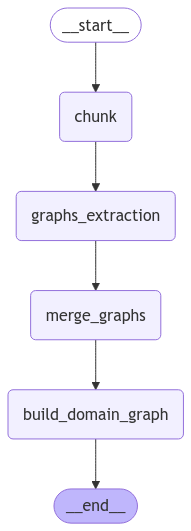

In [228]:
display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [229]:
state_input = {"text": text, "ontology_str": ontology_1, "ontology_obj": form10k}
result = app.invoke(state_input)

Chunking...
Chunking DONE
Extracting Generic Graphs in Parallel...
Extracting Generic Graph DONE
Merging Graphs...
Building Domain Graphs in Parallel...


In [230]:
result['domain_graphs']

[[KnowledgeGraph_PartI_Business(metadata=Metadata(section='PartI', subsections=['Business']), nodes=[Node(id='AE', type='Company', properties={'name': 'Adams Resources', 'cik': '<UNKNOWN>'}), Node(id='business_section', type='Business', properties={'id': 'business_section', 'description': 'Adams Resources operates through subsidiaries in crude oil marketing and transportation services', 'employees': '741 as of December 31, 2023', 'regulatoryEnvironment': 'Regulated by U.S. Department of Transportation', 'seasonality': '<UNKNOWN>'}), Node(id='transportation_segment', type='BusinessSegment', properties={'name': 'Transportation Services'}), Node(id='crude_oil_segment', type='BusinessSegment', properties={'name': 'Crude Oil Marketing'}), Node(id='VEX_Pipeline', type='Product', properties={'name': 'Victoria Express Pipeline System'})], edges=[Edge(from_='AE', to='business_section', relationship='HAS_BUSINESS', properties={}), Edge(from_='AE', to='transportation_segment', relationship='HAS_S